# Gen2FirmwareDemo_25Nov4
**Author:** Ruixuan (Matt) Xie  
**Date:** November 4, 2025  

---

### Overview
This notebook provides the necessary functions for operating the **2-octave (Gen2) readout firmware**,  
valid for the following firmware design:  
**`4Chan1GHzReadout0_0.xsa`** (4-channel design)

---

> ⚠️ **Important Note:**  
> For version `4Chan1GHzReadout0_0.xsa`, **avoid enabling all 4 readout chains simultaneously**.  
> The RFSoC may exceed its dynamic power capacity if 3 or more chains are active at once.

# Imports

In [1]:
%matplotlib notebook

from pynq import Overlay
from pynq import MMIO
import xrfclk
import xrfdc
import numpy as np
from matplotlib import pyplot as plt
import time

# Firmware upload

In [2]:
# FIRMWARE UPLOAD
firmware = Overlay("4Chan1GHzReadout0_0.xsa",ignore_version=True)

# INITIALIZING PLLs
clksrc = 409.6 # MHz
xrfclk.set_all_ref_clks(clksrc)

# Firmware functions

In [3]:
# ---------------functions that involve overlay-----------------------------
def _firmware_chan(firmware, chan):
    """
    Returns the handle to the specified readout channel in the overlay firmware.

    Args:
        firmware (pynq.overlay.Overlay): 
            The uploaded overlay object.
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.

    Returns:
        pynq.overlay.DocumentHierarchy: 
            The firmware channel object corresponding to the requested channel.

    """
    return {
        1: firmware.chan1,
        2: firmware.chan2,
        3: firmware.chan3,
        4: firmware.chan4,
    }[chan]


def resetReadout(chan):
    '''
    Resets a readout chain.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        
    Notes: 
        Under-tested, do not use if run into issues with this.
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    chan_access.GPIO.axi_gpio_0.write(0x0,2)


def startReadout(chan):
    '''
    Starts a readout chain.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
            
    Notes: 
        In the 4 chain design, starting chan1 will start all chans.
        This behaviour can be modified if desired.
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    chan_access.GPIO.axi_gpio_0.write(0x0,0)
    chan_access.GPIO.axi_gpio_0.write(0x0,1)


def set_NCLO(chan, lofreq):
    '''
    Sets the coarse NCLO frequency, which shifts the output spectrum in a readout chain.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        lofreq: 
            Frequency in MHz.
            
    Notes: 
        Shifting in frequency with this function scrambles the time stream phase.
        This function is different from the gen1 counterpart, in the minus sign for adc lofreq.
    '''
    import xrfdc
    rf_data_conv = firmware.usp_rf_data_converter_0
    
    if chan == 1:
        rf_data_conv.adc_tiles[1].blocks[0].MixerSettings['Freq']=-lofreq
        rf_data_conv.dac_tiles[1].blocks[3].MixerSettings['Freq']=lofreq
        rf_data_conv.adc_tiles[1].blocks[0].UpdateEvent(xrfdc.EVENT_MIXER)
        rf_data_conv.dac_tiles[1].blocks[3].UpdateEvent(xrfdc.EVENT_MIXER)
    elif chan == 2:
        rf_data_conv.adc_tiles[1].blocks[1].MixerSettings['Freq']=-lofreq
        rf_data_conv.dac_tiles[1].blocks[2].MixerSettings['Freq']=lofreq
        rf_data_conv.adc_tiles[1].blocks[1].UpdateEvent(xrfdc.EVENT_MIXER)
        rf_data_conv.dac_tiles[1].blocks[2].UpdateEvent(xrfdc.EVENT_MIXER)
    elif chan == 3:
        rf_data_conv.adc_tiles[0].blocks[1].MixerSettings['Freq']=-lofreq
        rf_data_conv.dac_tiles[1].blocks[0].MixerSettings['Freq']=lofreq
        rf_data_conv.adc_tiles[0].blocks[1].UpdateEvent(xrfdc.EVENT_MIXER)
        rf_data_conv.dac_tiles[1].blocks[0].UpdateEvent(xrfdc.EVENT_MIXER)
    elif chan == 4:
        rf_data_conv.adc_tiles[0].blocks[0].MixerSettings['Freq']=-lofreq
        rf_data_conv.dac_tiles[1].blocks[1].MixerSettings['Freq']=lofreq
        rf_data_conv.adc_tiles[0].blocks[0].UpdateEvent(xrfdc.EVENT_MIXER)
        rf_data_conv.dac_tiles[1].blocks[1].UpdateEvent(xrfdc.EVENT_MIXER)
        
    else:
        return "Does not compute"
    return


def read_NCLO(chan):
    '''
    Reads the coarse NCLO frequency values set by calling set_NCLO().
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
            
    Notes: 
        This function should be identical to the gen1 counterpart.
    '''

    import xrfdc
    rf_data_conv = firmware.usp_rf_data_converter_0
    
    if chan == 1:
        nclo_freq_adc = rf_data_conv.adc_tiles[1].blocks[0].MixerSettings['Freq']
        nclo_freq_dac = rf_data_conv.dac_tiles[1].blocks[3].MixerSettings['Freq']
    elif chan == 2:
        nclo_freq_adc = rf_data_conv.adc_tiles[1].blocks[1].MixerSettings['Freq']
        nclo_freq_dac = rf_data_conv.dac_tiles[1].blocks[2].MixerSettings['Freq']
    elif chan == 3:
        nclo_freq_adc = rf_data_conv.adc_tiles[0].blocks[1].MixerSettings['Freq']
        nclo_freq_dac = rf_data_conv.dac_tiles[1].blocks[0].MixerSettings['Freq']
    elif chan == 4:
        nclo_freq_adc = rf_data_conv.adc_tiles[0].blocks[0].MixerSettings['Freq']
        nclo_freq_dac = rf_data_conv.dac_tiles[1].blocks[1].MixerSettings['Freq']
    else:
        return "Does not compute"
    return nclo_freq_adc, nclo_freq_dac


def setFFTscale(chan, scale=2016):
    '''
    Sets the internal scaling of the FFT module.
    
    Args: 
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        scale (ufix_10):
            Each HIGH bit enables shift to the right at the FFT stage.
            
    Notes: 
        FFT is on the receive side of DSP
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    gpio_4_slot_2_word = int(scale)
    chan_access.GPIO.axi_gpio_4.write(0x08,gpio_4_slot_2_word)
    
    
def setAccumLenAndSnapBinLen(chan, acc_factor, bin_len, parallel_factor=4, psb_channel_count=2048):
    '''
    Sets the accumulation factor (averaging length) in the receive DSP, which will impact output rate.
    Modifies the data structure returned by getSnapData(*, mux_sel=3).
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        acc_factor (int): 
            The accumulation length of receive outputs (the length of avg filter).
        bin_len (int): 
            Determines the number of clk cycles to be captured by getSnapData(mux_sel=3), accepts value in [5,512].
                Example: 
                    Capture all 2048 bins if set to 512,
                    1024 bins if set to 256.
                       
    Notes:
        parallel_factor=4 and psb_channel_count=2048 are specific to gateware, not arbitrary,
        these values probably should be in a config file
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    acc_length = int(psb_channel_count/parallel_factor * acc_factor - 4)
    getAccumChan = int(bin_len - 3)
    
    chan_access.GPIO.axi_gpio_3.write(0x00, getAccumChan * 2**23 + acc_length)


def resetSnap(chan):
    '''
    Refreshes the data buffer used by getSnapData()
    
    Args: 
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
            
    Note:
        Expect slight delay before data is ready for getSnapData() call
    '''
    access = _firmware_chan(firmware, chan).GPIO.axi_gpio_3
    access.write(0x08, 0)
    access.write(0x08, 3)
    access.write(0x08, 0)
            
            
def setPSBscaleConst(chan, C=2**15):
    '''
    Scales the magnitude of the waveform at the output of PSB, by C/2^15.
    
    Args: 
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        C (ufix_16):
            Output magnitude = input magnitude * C / 2^15.
            
    Notes: This is intended for scaling the PSB outputs to the DAC maximum range. It can cause overflow (saturation)
          if C is too large. The underlying mechanism needs refining.
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    chan_access.GPIO.axi_gpio_5.write(0x00,int(C))


def _writeTone(chan, mem, addr, dphi, init_re, init_im):
    '''
    Writes one tone, which is defined by its frequency (dphi) and initial vector (init_re, init_im).

    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        mem (int {0,1,2,3,4,5,6,7}): 
            An index that maps to one of the 8 BRAMs on 8 parallel paths.
        addr (uint): 
            The address of the write operation.
        dphi (float): 
            The step in phase which defines the frequency of the tone from bin center.
            Note: In unit [rad]
        init_re (float),
        init_im (float): 
            The real and imarinary parts of the initial vector.
            Note: The maximum magnitude of the initial vector is 1.
    
    Notes: Currently not possible to only change the frequency of the tone without setting its initial vector
          need to seperate the write_enable signal in firmaware to do that if desired.
    '''
    
    chan_access = _firmware_chan(firmware, chan)
    
    init_re_write = _to_xbit_unsigned(int(np.round(init_re * 2**16)), 18)
    init_im_write = _to_xbit_unsigned(int(np.round(init_im * 2**16)), 18)
    chan_access.GPIO.axi_gpio_2.write(0x00,init_re_write)
    chan_access.GPIO.axi_gpio_2.write(0x08,init_im_write)
    
    # toggle we for the corresponding memory block, addr and data shared
    if mem == 0:
        dphi_write,_ = _rad2int(dphi)
        # Ready the addr and data before toggling we
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,1)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
    elif mem == 2:
        dphi_write,_ = _rad2int(dphi)
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,2)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
    elif mem == 4:
        dphi_write,_ = _rad2int(dphi)
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,4)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
    elif mem == 6:
        dphi_write,_ = _rad2int(dphi)
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,8)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        
    elif mem == 1:
        # actual dphis for odd indexed channels are 180 degrees rotated
        dphi_write,_ = _rad2int(_wrap_angle(dphi + np.pi))
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,16)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
    elif mem == 3:
        dphi_write,_ = _rad2int(_wrap_angle(dphi + np.pi))
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,32)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
    elif mem == 5:
        dphi_write,_ = _rad2int(_wrap_angle(dphi + np.pi))
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,64)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
    elif mem == 7:
        dphi_write,_ = _rad2int(_wrap_angle(dphi + np.pi))
        gpio_1_slot_2_word = int((addr<<16) + dphi_write)
        chan_access.GPIO.axi_gpio_1.write(0x08,gpio_1_slot_2_word)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)
        chan_access.GPIO.axi_gpio_1.write(0x00,128)
        chan_access.GPIO.axi_gpio_1.write(0x00,0)

        
def _loadAllTones(chan, bin_num, dphi, init_re, init_im):
    '''
    Writes all tones listed in 1darrays
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        bin_num (int);
            The FFT bin number of which the tone is in.
        dphi (float): 
            The step in phase which defines the frequency of the tone from bin center.
            Note: In unit [rad]
        init_re (float),
        init_im (float): 
            The real and imarinary parts of the initial vector.
            Note: The maximum magnitude of the initial vector is 1.
    
    '''
    for i in range(bin_num.size):
        _writeTone(chan, bin_num[i]%8, bin_num[i]//8, dphi[i], init_re[i], init_im[i])

        
def clearAllTones(chan):
    '''
    Writes zeros to all tone parameters.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
            
    Notes: To keep a tone going while suppressing it's power,
          simply write 0 amp to it while keeping dphi and init vector
          There's another option to suppress tones in toneSelect
    '''
    for addr in range(256):
        for mem in range(8):
            _writeTone(chan, mem, addr, 0, 0, 0)
        

def _writeToneSelect(chan, addr, data):
    '''
    Updates toneSelect parameter memory at one address
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        addr (uint): 
            The address of the write operation.
        data (ufix_12):
            The data of the write operation.
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    gpio_6_slot_2_word = int(addr)
    chan_access.GPIO.axi_gpio_6.write(0x08,gpio_6_slot_2_word)
    
    gpio_7_slot_1_word = int((data[1] << 12) + data[0])
    chan_access.GPIO.axi_gpio_7.write(0x00,gpio_7_slot_1_word)
    gpio_7_slot_2_word = int((data[3] << 12) + data[2])
    chan_access.GPIO.axi_gpio_7.write(0x08,gpio_7_slot_2_word)
    gpio_8_slot_1_word = int((data[5] << 12) + data[4])
    chan_access.GPIO.axi_gpio_8.write(0x00,gpio_8_slot_1_word)
    gpio_8_slot_2_word = int((data[7] << 12) + data[6])
    chan_access.GPIO.axi_gpio_8.write(0x08,gpio_8_slot_2_word)
    
    chan_access.GPIO.axi_gpio_6.write(0x00,0)
    chan_access.GPIO.axi_gpio_6.write(0x00,1)
    chan_access.GPIO.axi_gpio_6.write(0x00,0)
    
    
def _writeToneSelectAll(chan, ToneSelMap):
    '''
    Updates the entire toneSelect LUT from ToneSelMap
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        ToneSelMap (numpy.ndarray):
            The toneSelect LUT.
    '''
    for i in range(256):
        _writeToneSelect(chan, i, ToneSelMap[i])
        

def _updateToneSelMap(chan, toneSelectInfo, turn_off_unused_bin=True):
    '''
    It updates the init toneSelMap base on the toneSelectInfo.
    Used in case of 2 tones per bin. 
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        toneSelectInfo (numpy.ndarray):
            An array with bin reuse mapping information.
        turn_off_unused_bin (bool):
            True: remove the duplicate tone from bin reuse mechanism.
    '''
    toneSelectMap = genInitToneSelMap()
    for value in toneSelectInfo.T:
        twoTone_bin, unused_bin = value
        temp = toneSelectMap[unused_bin//8, unused_bin%8]
        toneSelectMap[twoTone_bin//8, twoTone_bin%8] = temp
        if turn_off_unused_bin:
            toneSelectMap[unused_bin//8, unused_bin%8] = 0
    _writeToneSelectAll(chan, toneSelectMap)
    
    
def _writeBinMap(chan, addr, data):
    '''
    Write to firmware registers via GPIO.
    Updates the bin select mapping (LUT) in the receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        addr (uint): 
            The address of the write operation.
        data (ufix_22):
            The data of the write operation.
            
    Notes:
        The bin map RAM are accecced 2 addrs at a time, 
        only the first addr need to be supplied, each addr take two values
        each 11 bits concatenated.
        For example, if addr=n, then 
        concact(data[1],data[0])LSB -> addr n
        concact(data[3],data[2])LSB -> addr n+1
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    gpio_9_slot_1_word = int((data[1]<<21) + (data[0]<<10) + addr)
    chan_access.GPIO.axi_gpio_9.write(0x00, gpio_9_slot_1_word)
    gpio_9_slot_2_word = int((data[3]<<12) + (data[2]<<1) + 0)
    chan_access.GPIO.axi_gpio_9.write(0x08, gpio_9_slot_2_word)
    
    gpio_9_slot_2_word = int((data[3]<<12) + (data[2]<<1) + 1)
    chan_access.GPIO.axi_gpio_9.write(0x08, gpio_9_slot_2_word)
    gpio_9_slot_2_word = int((data[3]<<12) + (data[2]<<1) + 0)
    chan_access.GPIO.axi_gpio_9.write(0x08, gpio_9_slot_2_word)
    
def _loadBinMap(chan, bin_map):
    '''
    Updates the bin select mapping (LUT) in the receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        bin_map (numpy.ndarray):
            Array of bin select mapping LUT.
    '''
    bin_map_reshape = bin_map.reshape((512, 4))
    for i in range(512):
        _writeBinMap(chan, 2*i, bin_map_reshape[i])
        

def initBinMap(chan):
    '''
    Initialize the bin select mapping (LUT) to default natural order (0,1,2,...).
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
    '''
    _loadBinMap(chan, np.arange(2048, dtype='int'))
    
    
def _writeBeatDphi(chan, mem, addr, beatDphi):
    '''
    Write to firmware registers via GPIO.
    Updates the beat frequencies corresponding to each tone, 
    for the digital down conversion (DDC) in receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        mem (int {0,1,2,3}):
            An index that maps to one of the 4 BRAMs on 4 parallel paths.
        addr (uint): 
            The address of the write operation.
        beatDphi (float):
            The step in phase that defines the beat frequency, in unit [rad].     
    '''
    chan_access = _firmware_chan(firmware, chan)
    
    beatDphi_write,_ = _rad2int(beatDphi)
    gpio_4_slot_1_word = int((addr << 20) + (beatDphi_write << 4))
    
    chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    if mem == 0:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**0)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    elif mem == 1:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**1)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    elif mem == 2:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**2)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
    elif mem == 3:
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word + 2**3)
        chan_access.GPIO.axi_gpio_4.write(0x00,gpio_4_slot_1_word)
        
        
def _loadBeatDphiMap(chan, beat_dphi_map):
    '''
    Updates the beat frequencies corresponding to each tone, 
    for the digital down conversion (DDC) in receive.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        beat_dphi_map (numpy.ndarray):
            beat dphi LUT values.
    '''
    beat_dphi_map_reshape = beat_dphi_map.reshape((512, 4))
    for addr in range(512):
        for mem in range(4):
            _writeBeatDphi(chan, mem, addr, beat_dphi_map_reshape[addr, mem])


def writeComb(chan, freqs, amps, phi):
    '''
    Writes a comb of frequencies from user specified frequencies, amplitudes (magnitudes) and phases.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        freqs(numpy.1darray):
            A list of frequencies, within 1GHz bandwidth, centered at DC.
        amps (numpy.1darray):
            The normalized magnitude of each frequency, maximum = 1.0.
        phi (numpy.1darray):
            The phases of each frequency, in [rad].
    Returns:
        freqs_actual (numpy.1darray)
        bin_map (numpy.1darray)
        transmit_bin_count (int)
        secondTone_flag (bool)
        
    Notes:
        Generate optimal phases with genBestPhis() and always clearAllTones() before writing new combs.
    '''
    turn_off_unused_bin = True
    fs = 1.024e9
    f_center = 1.024e9  # Hz
    psb_channel_count = 2048
    
    init_re, init_im = _phase2vector(phi, amps)
    
    _,freqs_actual = _genWave(freqs, amps, phi)  # should make freqs_actual a stand alone function
    
    bin_num = np.round(freqs_actual/(fs/psb_channel_count)).astype(np.int64)
    
    # dphi/2pi ratio corresponds to the channel bandwidth of PSB which is 2*fs/2048
    dphi = _wrap_angle(np.pi*(freqs_actual/(fs/psb_channel_count) - bin_num))
    beat_dphi = _wrap_angle(-2*dphi)  # Careful with different sampling frequency
    
    # Represent bin numbers with all positive values
    temp = bin_num < 0
    bin_num[temp] += 2048
    
    bin_count = np.bincount(bin_num, minlength=2048)
    
    bin_map = np.zeros(2048, dtype=int)
    beat_dphi_map = np.zeros(2048, dtype=float)
    beat_dphi_2048 = np.zeros(2048, dtype=float)
    
    # For any two tones per bin instances, the second bin index will be replaced
    # with an unused bin index, and this mapping is saved in toneSelectInfo
    second_tone_index = _find_second_instance_indices(bin_num)
    if second_tone_index.size > 0:
        secondTone_flag = True
        toneSelectInfo = np.zeros((2,second_tone_index.size), dtype=int)
        toneSelectInfo[0] = bin_num[second_tone_index]
        all_bins = np.arange(2048)
        unused_bins = np.setdiff1d(all_bins, bin_num)
        bin_num[second_tone_index] = unused_bins[0:second_tone_index.size]
        toneSelectInfo[1] = bin_num[second_tone_index]
        
        _updateToneSelMap(chan, toneSelectInfo, turn_off_unused_bin)
        
        beat_dphi_2048[bin_num] = beat_dphi
        temp = beat_dphi_2048[toneSelectInfo[1]]
        beat_dphi_2048[toneSelectInfo[1]] = 0
        beat_dphi_2048_stack = np.vstack([beat_dphi_2048,beat_dphi_2048])
        beat_dphi_2048_stack[1, toneSelectInfo[0]] = temp

        transmit_bin_count = 0
        for i in range(2048):
            if bin_count[i] == 2:
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048_stack[0, i]
                transmit_bin_count += 1
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048_stack[1, i]
                transmit_bin_count += 1
            elif bin_count[i] == 1:
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048_stack[0, i]
                transmit_bin_count += 1
    else:
        secondTone_flag = False
        _writeToneSelectAll(chan, genInitToneSelMap())
        
        beat_dphi_2048[bin_num] = beat_dphi
        transmit_bin_count = 0
        for i in range(2048):
            if bin_count[i] == 1:
                bin_map[transmit_bin_count] = i
                beat_dphi_map[transmit_bin_count] = beat_dphi_2048[i]
                transmit_bin_count += 1

    _loadBinMap(chan, bin_map)
    _loadBeatDphiMap(chan, beat_dphi_map)
    
    _loadAllTones(chan, bin_num, dphi, init_re, init_im)
    np.savetxt(f"twoOctaveReadout_files/bin_num_{chan}.csv", bin_num, delimiter=",")
    np.savetxt(f"twoOctaveReadout_files/dphi_{chan}.csv", dphi, delimiter=",")
    np.savetxt(f"twoOctaveReadout_files/init_re_{chan}.csv", init_re, delimiter=",")
    np.savetxt(f"twoOctaveReadout_files/init_im_{chan}.csv", init_im, delimiter=",")
    np.savetxt(f"twoOctaveReadout_files/beat_dphi_map_{chan}.csv", beat_dphi_map, delimiter=",")
    
    freqs_rf_actual = freqs_actual + f_center
    
    np.savetxt(f"twoOctaveReadout_files/f_rf_tones_comb_{chan}.csv", freqs_rf_actual, delimiter=",")
    np.savetxt(f"twoOctaveReadout_files/a_tones_comb_{chan}.csv", np.array([amps]), delimiter=",")
    np.savetxt(f"twoOctaveReadout_files/p_tones_comb_{chan}.csv", phi, delimiter=",")
    np.save('twoOctaveReadout_files/f_rf_tones_comb_cust.npy', freqs_rf_actual)
    np.save('twoOctaveReadout_files/a_tones_comb_cust.npy', np.array([amps]))
    np.save('twoOctaveReadout_files/p_tones_comb_cust.npy', phi)
    
    return freqs_actual, bin_map, transmit_bin_count, secondTone_flag


def shiftInBin(chan, f_shift):
    '''
    Shifts an individual tone within the bin bandwidth.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        f_shift (float):
            frequency of shift.
            
    Notes:
        PSB bin bandwidth = 1 MHz
    '''
    dphi_shift = (f_shift/1e6) * 2*np.pi
    bin_num = np.loadtxt(f"twoOctaveReadout_files/bin_num_{chan}.csv", delimiter=",").astype(np.int64)
    dphi = np.loadtxt(f"twoOctaveReadout_files/dphi_{chan}.csv", delimiter=",")
    init_re = np.loadtxt(f"twoOctaveReadout_files/init_re_{chan}.csv", delimiter=",")
    init_im = np.loadtxt(f"twoOctaveReadout_files/init_im_{chan}.csv", delimiter=",")
    beat_dphi_map = np.loadtxt(f"twoOctaveReadout_files/beat_dphi_map_{chan}.csv", delimiter=",")
    _loadAllTones(chan, bin_num, dphi+dphi_shift, init_re, init_im)
    _loadBeatDphiMap(chan, beat_dphi_map - 2 * dphi_shift)
    
    
def getSnapData(chan, mux_sel):
    '''
    Fetch data from firmware DSP.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        mux_sel:
            0: ADC outputs
            1: PSB outputs (DAC inputs)
            3: Receive outputs (time stream data)
    Returns:
        I, Q (numpy.ndarray):
            for data converter data, I and q are flat,
            for time stream data, I and Q have shape (n, bin)
    '''
    import numpy as np
    from pynq import MMIO
    
    match chan:
        case 1:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A001_0000
                case 3:
                    base_addr_wide  = 0x00_A002_0000
        case 2:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A003_0000
                case 3:
                    base_addr_wide  = 0x00_A004_0000
        case 3:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A005_0000
                case 3:
                    base_addr_wide  = 0x00_A006_0000
        case 4:
            match mux_sel:
                case 0 | 1:
                    base_addr_wide  = 0x00_A007_0000
                case 3:
                    base_addr_wide  = 0x00_A008_0000
                    
    max_count = 65536  # 32x2048 = 65536
    mmio_wide_bram = MMIO(base_addr_wide , max_count)
    wide_data = mmio_wide_bram.array[0:16384]  # max/4, bram depth*word_bits/32bits
    
    I = np.zeros(8192)
    Q = np.zeros(8192)
    
    match mux_sel:
        case 0 | 1:
            up_PSB_q0, lw_PSB_i0 = np.int16(wide_data[0::8] >> 16), np.int16(wide_data[0::8] & 0x0000ffff)
            up_PSB_q1, lw_PSB_i1 = np.int16(wide_data[1::8] >> 16), np.int16(wide_data[1::8] & 0x0000ffff)
            up_PSB_q2, lw_PSB_i2 = np.int16(wide_data[2::8] >> 16), np.int16(wide_data[2::8] & 0x0000ffff)
            up_PSB_q3, lw_PSB_i3 = np.int16(wide_data[3::8] >> 16), np.int16(wide_data[3::8] & 0x0000ffff)
            up_ADC_i1, lw_ADC_i0 = np.int16(wide_data[4::8] >> 16), np.int16(wide_data[4::8] & 0x0000ffff)
            up_ADC_i3, lw_ADC_i2 = np.int16(wide_data[5::8] >> 16), np.int16(wide_data[5::8] & 0x0000ffff)
            up_ADC_q1, lw_ADC_q0 = np.int16(wide_data[6::8] >> 16), np.int16(wide_data[6::8] & 0x0000ffff)
            up_ADC_q3, lw_ADC_q2 = np.int16(wide_data[7::8] >> 16), np.int16(wide_data[7::8] & 0x0000ffff)
            
            if mux_sel == 0:
                I[0::4] = lw_ADC_i0
                I[1::4] = up_ADC_i1
                I[2::4] = lw_ADC_i2
                I[3::4] = up_ADC_i3
                Q[0::4] = lw_ADC_q0
                Q[1::4] = up_ADC_q1
                Q[2::4] = lw_ADC_q2
                Q[3::4] = up_ADC_q3
            elif mux_sel == 1:
                I[0::4] = lw_PSB_i0
                I[1::4] = lw_PSB_i1
                I[2::4] = lw_PSB_i2
                I[3::4] = lw_PSB_i3
                Q[0::4] = up_PSB_q0
                Q[1::4] = up_PSB_q1
                Q[2::4] = up_PSB_q2
                Q[3::4] = up_PSB_q3
        case 3:
            i0 = (np.int32(wide_data[0::8])).astype("float")
            q0 = (np.int32(wide_data[1::8])).astype("float")
            i1 = (np.int32(wide_data[2::8])).astype("float")
            q1 = (np.int32(wide_data[3::8])).astype("float")
            i2 = (np.int32(wide_data[4::8])).astype("float")
            q2 = (np.int32(wide_data[5::8])).astype("float")
            i3 = (np.int32(wide_data[6::8])).astype("float")
            q3 = (np.int32(wide_data[7::8])).astype("float")
            
            I[0::4] = i0
            I[1::4] = i1
            I[2::4] = i2
            I[3::4] = i3
            Q[0::4] = q0
            Q[1::4] = q1
            Q[2::4] = q2
            Q[3::4] = q3
            
#             I /= 2**14
#             Q /= 2**14
    return I, Q


def set_fine_nco_frequency(chan, freq_mhz):
    """
    Set the fine NCO (Numerically Controlled Oscillator) frequency.
    
    Args:
        chan (int): 
            Channel index (1–4) specifying which readout chain to access.
        freq_mhz (float);
            Frequency in MHz.
    """

    import numpy as np

    try:
        # Constants
        fs_hz = 1.024e9                    # System sample rate (Hz); 512e6 Hz
        nco_bits = 22                      # Width of NCO phase accumulator
        freq_resolution_hz = fs_hz / 2**nco_bits  # Frequency step per integer DTW

        # Convert desired frequency (MHz) to Hz
        freq_hz = freq_mhz * 1e6

        # --- Optional coherence quantization (align to packet sample rate) ---
        fft_len = 1024
        num_bins = 2048
        packet_rate_hz = fs_hz / (fft_len * num_bins)  # ≈ 488.28125 Hz
        freq_hz = np.round(freq_hz / packet_rate_hz) * packet_rate_hz
        # ---------------------------------------------------------------------

        # Compute digital tuning word (DTW)
        dtw = int(np.round(freq_hz / freq_resolution_hz))

        # Actual frequency that will be set
        actual_freq_hz = dtw * freq_resolution_hz

        # Write DTW to firmware register for the given channel
        chan_access = _firmware_chan(firmware, chan)
        chan_access.GPIO.axi_gpio_10.write(0x00,dtw)

    except Exception as e:
        print(f"set_fine_nco_frequency Error: {e}")

            
# ----------------------functions that don't involve overlay-----------------
def get_safe_frequencies(freqs):
    """
    Filters the input frequencies based on system limitations.
    
    Args:
        freqs (array-like): Input frequencies in Hz.
    
    Returns:
        np.ndarray: Safe frequencies satisfying the limitations.
    """
    freqs = np.asarray(freqs)
    
    # Limitation 1: Filter frequencies within [-500e6, 500e6] Hz
    mask = (freqs >= -500e6) & (freqs <= 500e6)
    freqs = freqs[mask]
    
    if len(freqs) == 0:
        return np.array([])
    
    # Define bin parameters
    bin_size = 5e5  # 500 kHz
    offset = 2.5e5  # 250 kHz
    
    # Compute bin indices
    bins = np.floor((freqs + offset) / bin_size)
    
    # Get unique bin indices
    unique_bins = np.unique(bins)
    
    # Collect kept frequencies
    kept = []
    
    for b in unique_bins:
        # Get frequencies in this bin
        in_bin_mask = (bins == b)
        in_bin_freqs = freqs[in_bin_mask]
        
        if len(in_bin_freqs) <= 2:
            kept.append(in_bin_freqs)
        else:
            # Randomly select 2 frequencies
            selected = np.random.choice(in_bin_freqs, size=2, replace=False)
            kept.append(selected)
    
    # Concatenate and return
    safe_freqs = np.concatenate(kept)
    return safe_freqs


def genInitToneSelMap():
    '''
    Generate a default tone select mapping LUT for initialization/reset.
    
    Returns:
        toneSelectMap (numpy.ndarray)
    '''
    toneSelectMap = np.arange(2048, dtype=np.uint16).reshape((256,8))
    for i in range(8):
        addr = np.arange(256, dtype=np.uint16)
        para = np.ones(256, dtype=np.uint16) * i
        onoff = np.ones(256, dtype=np.uint16)
        toneSelectMap[:, i] = addr << 4 | para << 1 | onoff
    return toneSelectMap


def decodeToneSelMap(concatenated):
    '''
    This function decodes the tone select mapping values to human readable parameters.
    The tone select mapping values are three-value concatenated big integer.
    
    Returns:
        addr: address of the bin
        para: parallel path index
        onoff: turn on or off the bin
    '''
    onoff = concatenated & 0b1
    para = (concatenated & 0b1110) >> 1
    addr = concatenated >> 4
    return addr, para, onoff


def _find_second_instance_indices(freqs):
    '''
    This function is for finding the index of two tones per bin, for the bin re-assign of the second tones.
    
    Args:
        freqs (numpy.1darray): 
            assume to be in assending order
    Returns:
        second_indices (numpy.1darray):
            the indices of the second tones.
    '''
    # Find where consecutive elements are equal
    is_repeat = np.diff(freqs) == 0
    # Get indices of second instances (where is_repeat is True, take the next index)
    second_indices = np.where(is_repeat)[0] + 1
    return second_indices


def findMaxMagnitude(x):
    '''
    Args:
        x (numpy.ndarray): an array of complex values
    Returns:
        max (float): the maximum magnitude among the complex values
    '''
    return np.max(np.abs(x))
    
    
def _genWave(freqs, amps, phis, fs=1.024e9, lut_len=2**21):
    '''
    Generates a waveform based on requested frequencies, magnitudes, and phases, using np.fft.ifft
    
    Notes:
        Since 2-octave firmware use PSB to synthesize wave, this is only used for genAmpsAndPhis.
    '''
    freqs = np.real(freqs)
    amps  = np.real(amps)
    phis  = np.real(phis)
    
    # Compute frequency bins
    bin_num      = np.round(freqs/(fs/lut_len)).astype(np.int64)
    freqs_actual = bin_num*(fs/lut_len)
    
    # Vectorized X assignment (frequency space)
    X    = np.zeros(lut_len, dtype=np.complex128)
    X[bin_num] = np.exp(-1j*phis)*amps
    
    # Compute IFFT
    x = np.fft.ifft(X, norm='backward')*lut_len
    
    return x, freqs_actual

def genBestPhis(freqs, magnitude=1.0, phase_trials=5):  
    '''
    Generates optimized phases for a set of frequencies to minimize waveform peak (crest factor).

    This function finds optimal phases for a set of sinusoidal components with given frequencies and magnitude, aiming to reduce the peak amplitude of the resulting composite waveform. It initializes amplitudes with equal values and then iteratively searches for optimal phases by randomly sampling and evaluating
    the waveform's peak. This is intended for tones to make best use of DAC's dynamic range.

    Args:
        freqs (numpy.ndarray): An array of frequencies (Hz) for the sinusoidal components.
        magnitude (float, optional): The magnitude of tones. Defaults to 1.0, which is the maximum.
        phase_trials (int, optional): The number of random phase sets to try. Defaults to 5.

    Returns:
        - best_phis (numpy.ndarray): An array of optimized phases (radians).
        - best_peak (float): The waveform peak given by the best phases

    Notes:
        - Phases are randomly sampled within the range [-pi, pi].
        To do: remove magnitude
    '''
    # number of tones
    N = len(freqs) 

    # assuming equal amplitudes
    mag = np.ones(N) * magnitude
    
    # sample random phases, choose best
    best_peak = float('inf')
    best_phis = None
    for _ in range(phase_trials):
        phis = np.random.uniform(-np.pi, np.pi, N)
        x,freqs_actual = _genWave(freqs, mag, phis)
        peak = findMaxMagnitude(x)
        if peak < best_peak:
            best_peak = peak
            best_phis = phis
            best_crest_factor = compute_crest_factor(x)
    
    return best_phis, freqs_actual, best_peak, best_crest_factor


def _phase2vector(phi, magnitude):
    '''
    Converts complex number from polar form to Cartesian form.
    '''
    Z = magnitude * np.exp(1.j*phi)
    return Z.real, Z.imag


def _to_xbit_unsigned(value, bit_width):
    '''
    Convert negative integer to an x-bit two's complement.
    
    Args:
        value (int)
        bit_width: total number of bits of the fix-point representation
        
    Notes:
        Calculate two's complement as 2^bit_width - abs(value)
    '''

    if value < 0:
        unsigned_value = (1 << bit_width) + value
    else:
        unsigned_value = value
    
    # Mask to ensure the value is within x bits
    return unsigned_value & ((1 << bit_width) - 1)


def _wrap_angle(angle):
    '''
    Args:
        angle (float):
            An angle in [rad].
    Returns:
        (float):
            An equavalent angle within the range [-pi,pi].
    '''
    return np.arctan2(np.sin(angle), np.cos(angle))


def _wrap_norm_angle(angle_pi_rad):
    '''
    Wrap the angle to the range [-pi, pi), with unit [pi rad].
    '''
    wrapped_angle = (angle_pi_rad + 1) % 2 - 1
    if wrapped_angle >= 1:
        wrapped_angle -= 2
    return wrapped_angle


def _rad2int(angle_rad):
    '''
    Convert any angle in rad to the uint16 representation in unit [pi rad]
    '''
    wrap = _wrap_angle(angle_rad)
    angle_pi_rad = wrap / np.pi
    scaled_angle_pi_rad = int(np.round(angle_pi_rad * 2**15))
#     if scaled_angle_pi_rad >= 32768:
#         scaled_angle_pi_rad = int(32767)
    angle_actual = np.int16(scaled_angle_pi_rad) * np.pi / 2**15
    return np.uint16(scaled_angle_pi_rad), angle_actual

# ------------------for data analysis and plotting---------------------------
def db(value):
    """ Convert linear value to dB value """
    return 20. * np.log10(np.abs(value) + 1e-12)


def db_relative(value):
    """ Convert linear value to dB value, normalize max to 0dB """
    magnitude = np.abs(value)
    return 20. * np.log10(magnitude / np.max(magnitude) + 1e-12)


def print_min_max(array):
    """
    reutrns the maximum and minimum absulute value in the array
    """
    print(f"{np.min(np.abs(array))} <-> {np.max(np.abs(array))}")


def compute_crest_factor(signal):
    peak_value = np.max(np.abs(signal))
    rms_value = np.sqrt(np.mean(np.abs(signal) ** 2))
    crest_factor = 20 * np.log10(peak_value / rms_value)
    return crest_factor

# Initialization after firmware upload

In [4]:
# SET ETHERNET IPS and MACS
def ethRegsPortWrite(eth_regs,
                     src_ip_int32   = int("c0a80335",16), # 192.168.3.53
                     dst_ip_int32   = int("c0a80328",16), # 192.168.3.40
                     src_mac0_int32 = int("eec0ffee",16), # 238.192.255.238
                     src_mac1_int16 = int("c0ff",16),     # 192.255
                     dst_mac0_int16 = int("ec18",16),  # last four hex of mac   # 14:eb:b6:52:ec:18(TP-Link_52:ec:18)
                     dst_mac1_int32 = int("14ebb652",16)): # first eight hex of mac
    eth_regs.write( 0x00, src_mac0_int32) 
    eth_regs.write( 0x04, (dst_mac0_int16<<16) + src_mac1_int16)
    eth_regs.write( 0x08, dst_mac1_int32)
    eth_regs.write( 0x0c, src_ip_int32)
    eth_regs.write( 0x10, dst_ip_int32)
# 00:1b:21:ed:5c:f6    
ethRegsPortWrite(firmware.ethWrapPort0.eth_regs_0, src_ip_int32=int("c0a80332",16)) # 192.168.3.50
ethRegsPortWrite(firmware.ethWrapPort1.eth_regs_0, src_ip_int32=int("c0a80333",16)) # 192.168.3.51
ethRegsPortWrite(firmware.ethWrapPort2.eth_regs_0, src_ip_int32=int("c0a80334",16)) # 192.168.3.52
ethRegsPortWrite(firmware.ethWrapPort3.eth_regs_0, src_ip_int32=int("c0a80335",16)) # 192.168.3.53

# Initialization
accum_len = 2048/4*1024
accum_start_gap = accum_len//4
firmware.eth_timing_ctrl.write(0x00, int(accum_start_gap - 4))  # the gap in clk cycles in between chan start signal

for chan in range(1,5):
    set_NCLO(chan, 1024)
    setFFTscale(chan, scale=2016)
    setAccumLenAndSnapBinLen(chan, 1024, 256)
    setPSBscaleConst(chan, C=37170)  # 37170

In [5]:
for chan in range(1,5):
    set_fine_nco_frequency(chan, 0)  # MHz

In [6]:
for chan in range(1,5):
    clearAllTones(chan)  # Gateware design comes with preloaded parameters, can discuss perfered preload

# Start readout

In [7]:
startReadout(1)  # always start with chan1, other chans follow the start of chan1

# Example: Request a list of frequencies

In [8]:
chan_under_test = 2

In [9]:
# Create an frequency list
num_tones = 1024

# freqs = np.array(np.linspace(-400.00e6, 400.00e6, num_tones))
# freqs = np.array(np.linspace(-250.00e6, 250.00e6, num_tones))
# freqs = np.loadtxt("scheduled_850_tones.csv", delimiter=',')
freqs = np.arange(-256e6, 256e6, 500e3)  # 1024 tones
# freqs = np.arange(-250e6, 250e6, 500e3)  # 1000 tones
# freqs = np.arange(0, 500e6, 500e3)
# freqs = np.array([0.5e6, 1e6, 1.1e6, 1.5e6]) + 2e6
# freqs = np.array([0.5e6, 1e6, 1.5e6]) + 2e6

safe_freqs = get_safe_frequencies(freqs)

In [10]:
# Write comb
amps = 1.0  # this value must not be greater than 1
best_phis, freqs_actual, peak, crest = genBestPhis(safe_freqs)
freqs_actual, bin_map, transmit_bin_count, secondTone_flag = writeComb(chan_under_test, safe_freqs, amps, best_phis)

## Data analysis & visualization

In [11]:
# Toggle AXI BRAM data capture reset
for chan in range(1,5):
    resetSnap(chan)

In [12]:
# get time stream snap data
I, Q = getSnapData(chan_under_test, 3)
result = (I + 1.j * Q)
result = result.reshape((-1, 1024))

print("magnitude range of result: ")
print_min_max(result)

result_power = np.abs(result)**2
sampling_rate = 1.024e9/(2048*1024)  # Hz
mean_power = np.mean(result_power, axis=0)
variance = np.var(result.real, axis=0) + np.var(result.imag, axis=0)
SNR = mean_power / variance
SNR_dBperHz = 10*np.log10(SNR) + 10*np.log10(sampling_rate)
print("SNR in each bin: \n", SNR_dBperHz[0:5])

print("time stream angle: ", np.angle(np.mean(result[:, 0])))

magnitude range of result: 
70944.35849311769 <-> 108553.33557749388
SNR in each bin: 
 [77.34349545 86.14297686 87.62389772 85.44706648 87.5721413 ]
time stream angle:  2.932253619678829


<IPython.core.display.Javascript object>


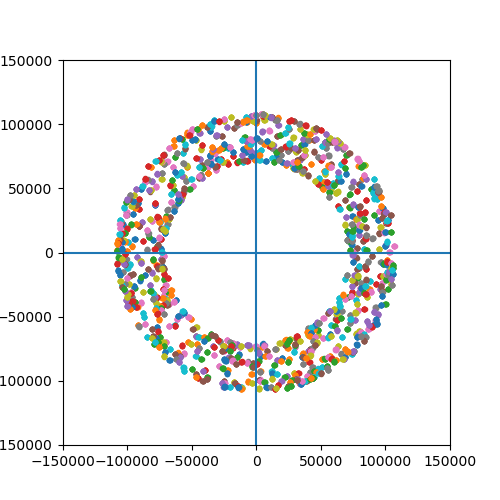

(-150000.0, 150000.0)

In [13]:
# Visualize time stream on the IQ plane
plt.figure(7, figsize=(5,5))
for i in range(1024):
    plt.plot(result[:, i].real, result[:, i].imag, ".")
plt.axvline(x=0)
plt.axhline(y=0)
plt.xlim(-150000, 150000)
plt.ylim(-150000, 150000)

<IPython.core.display.Javascript object>


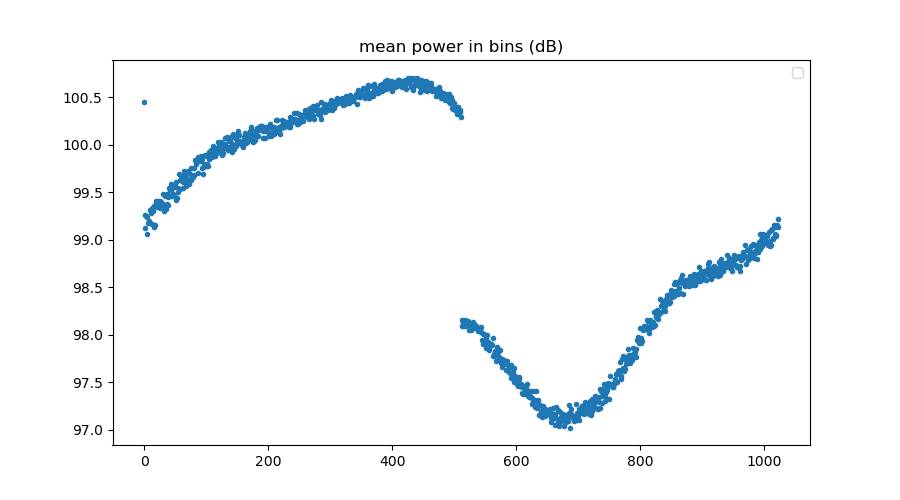

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [14]:
# Plot mean power of bins
meanPower_fig = plt.figure(1, figsize=(9, 5))
plt.title("mean power in bins (dB)")
plt.plot(10*np.log10(mean_power[0:1024]), '.', alpha=1)
# plt.ylim(70, 110)
plt.legend()
plt.show()

In [15]:
# get RF data converter snap data
I, Q = getSnapData(chan_under_test, 1)
PSB_out = (I + 1.j * Q)
I, Q = getSnapData(chan_under_test, 0)
ADC_out = (I + 1.j * Q)
print("PSB output range:")
print_min_max(PSB_out)
print("ADC output range:")
print_min_max(ADC_out)

PSB output range:
72.83543093852057 <-> 13047.66891057556
ADC output range:
3.0 <-> 1090.3797503622304


<IPython.core.display.Javascript object>


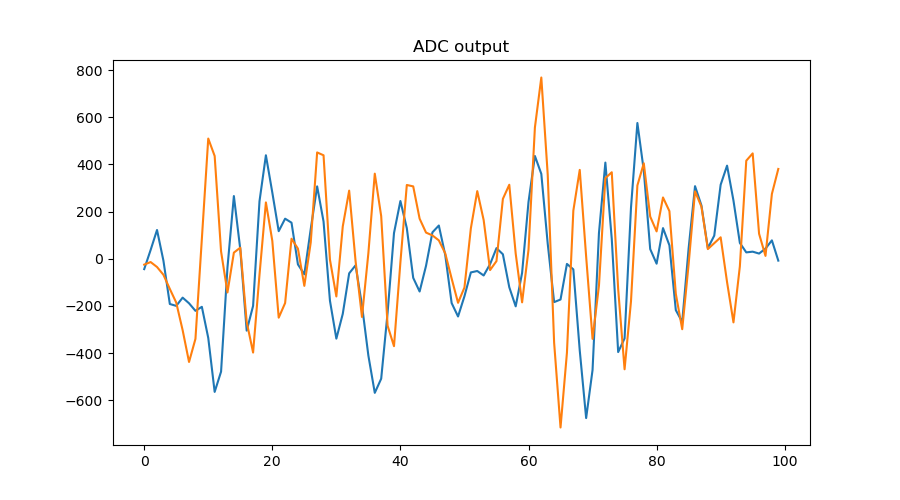

In [16]:
# plot ADC output
plt.figure(4, figsize=(9, 5))
plt.title("ADC output")
plt.plot(ADC_out.real[0:100])
plt.plot(ADC_out.imag[0:100])
plt.show()

<IPython.core.display.Javascript object>


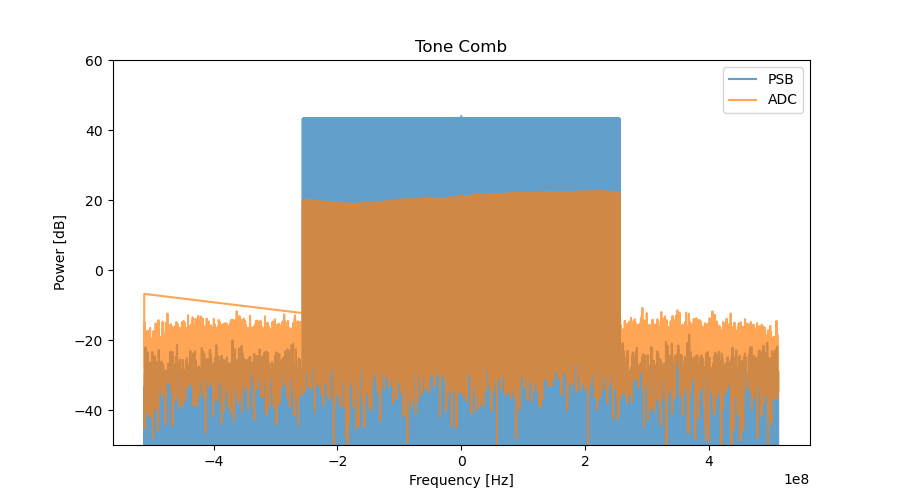

In [17]:
# Plot the spectrum of DAC input (PSB output) and ADC outputs
fs=1.024e9
fft_length = 8192
ADC_out_scale = 2**0

figComb = plt.figure(5, figsize=(9, 5))
plt.title(f"Tone Comb")
xf = np.fft.fftfreq(fft_length, 1./fs)
plt.plot(xf, db(np.fft.fft(PSB_out, fft_length)/fft_length), label='PSB', alpha=0.7)
plt.plot(xf, db(np.fft.fft(ADC_out*ADC_out_scale, fft_length)/fft_length), label='ADC', alpha=0.7) # , '.'
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [dB]")

plt.ylim(-50, 60)
plt.legend()
plt.show()